In [5]:
import pandas as pd

pi = pd.read_csv("tthermo_table.csv")[['proteinid', 'pI_x']]
packd = pd.read_csv("tthermopackingdensity.csv")[['accession', 'packing_density']]
fracdis = pd.read_csv("disorderfractionsplddt.csv")
cofactor = pd.read_csv("cofactorflags.csv")
moran50 = pd.read_excel("DataS1_Protein_Data_All_Conditions.xlsx", sheet_name='50 MPa')[['Accession', 'No. of Peptides (Significant Adj. P-Value)', 'No. of Peptides (Valid P-Value)']]
moran100 = pd.read_excel("DataS1_Protein_Data_All_Conditions.xlsx", sheet_name='100 MPa')[['Accession', 'No. of Peptides (Significant Adj. P-Value)', 'No. of Peptides (Valid P-Value)']]

packd = packd.rename(columns={'accession': 'proteinid'})
fracdis = fracdis.rename(columns={'Accession': 'proteinid'})
cofactor = cofactor.rename(columns={'accession_id': 'proteinid'})
moran100 = moran100.rename(columns={'Accession': 'proteinid'})
moran50 = moran50.rename(columns={'Accession': 'proteinid'})

In [8]:
tthermodf = pi.merge(packd, on='proteinid', how = 'inner')
print(f"After packing merge: {len(tthermodf)}")
tthermodf = tthermodf.merge(cofactor, on='proteinid', how = 'inner')
print(f"After cofactor merge: {len(tthermodf)}")
tthermodf = tthermodf.merge(fracdis, on='proteinid', how = 'inner')
print(f"After disorder merge: {len(tthermodf)}")
tthermodf = tthermodf.merge(moran100, on='proteinid', how = 'inner')
print(f"After moran100mpa merge: {len(tthermodf)}")
tthermodf = tthermodf.merge(moran50, on='proteinid', how = 'left')
print(f"After moran50mpa merge: {len(tthermodf)}")

After packing merge: 1225
After cofactor merge: 1225
After disorder merge: 1225
After moran100mpa merge: 1225
After moran50mpa merge: 1225


In [10]:
tthermodf = tthermodf.rename(columns={
    'No. of Peptides (Significant Adj. P-Value)_x': 'sigpeptides100',
    'No. of Peptides (Valid P-Value)_x': 'validpeptides100',
    'No. of Peptides (Significant Adj. P-Value)_y': 'sigpeptides50',
    'No. of Peptides (Valid P-Value)_y': 'validpeptides50'
})

In [14]:
tthermodf['fragile100'] = tthermodf['sigpeptides100'] >= 2
tthermodf['fragile50'] = tthermodf['sigpeptides50'] >= 2
tthermodf['fracperturbed100'] = tthermodf['sigpeptides100'] / tthermodf['validpeptides100']
tthermodf['fracperturbed50'] = tthermodf['sigpeptides50'] / tthermodf['validpeptides50']

In [15]:
tthermodf.to_csv("tthermofinaltable.csv", index = False)

In [26]:
def cofactorcategory(row):
    if row['has_covalent'] and row['has_divalent']:
        return 'both'
    elif row['has_covalent']:
        return 'covalent'
    elif row['has_divalent']:
        return 'divalent'
    else:
        return 'neither'

tthermodf['cofactors'] = tthermodf.apply(cofactorcategory, axis=1)
print(tthermodf['cofactors'].value_counts())
tthermodf = tthermodf.drop(columns=["cofactorflag"])
tthermodf.to_csv("tthermofinaltable.csv", index = False)

cofactors
neither     970
divalent    123
covalent    114
both         18
Name: count, dtype: int64


In [29]:
print(tthermodf[['pI_x', 'packing_density', 'Disorderfraction']].describe().round(4))
print()

for pressure, col in [('50 MPa', 'fragile50'), ('100 MPa', 'fragile100')]:
    n_frag = tthermodf[col].sum()
    n_total = tthermodf[col].notna().sum()
    print(f"{pressure}: {n_frag}/{n_total} proteins fragile "
          f"({100*n_frag/n_total:.1f}%)")

print()
print("Cofactor category counts:")
print(tthermodf['cofactors'].value_counts())

            pI_x  packing_density  Disorderfraction
count  1225.0000        1225.0000         1225.0000
mean      6.7788           0.7448            0.0221
std       1.6383           0.0193            0.0462
min       4.0500           0.6830            0.0000
25%       5.5978           0.7320            0.0000
50%       6.1968           0.7400            0.0046
75%       7.9053           0.7530            0.0267
max      11.8897           0.8500            0.6473

50 MPa: 131/1225 proteins fragile (10.7%)
100 MPa: 440/1225 proteins fragile (35.9%)

Cofactor category counts:
cofactors
neither     970
divalent    123
covalent    114
both         18
Name: count, dtype: int64


In [43]:
def run_chi2_binned(tthermodf, featurecol, fragilecol, binedges, binlabels):
    subset = tthermodf[[featurecol, fragilecol]].dropna().copy()

    subset['bin'] = pd.cut(subset[featurecol], bins=binedges, labels=binlabels,
                           include_lowest=True)
    subset = subset.dropna(subset=['bin'])

    subset['fragilestr'] = subset[fragilecol].map({True: 'fragile', False: 'notfragile'})
    ct = pd.crosstab(subset['bin'], subset['fragilestr'], margins=False)

    for val in ['notfragile', 'fragile']:
        if val not in ct.columns:
            ct[val] = 0
    ct = ct[['notfragile', 'fragile']]

    chi2, p, dof, expected = chi2_contingency(ct.values)

    ct['total'] = ct['notfragile'] + ct['fragile']
    ct['fracfragile'] = ct['fragile'] / ct['total']

    return {
        'table': ct,
        'chi2': chi2,
        'p': p,
        'dof': dof,
        'expected': expected,
        'smallexpected': (expected < 5).any(),
        'ntotal': len(subset),
    }

In [63]:
piedges = [0, 5, 6, 7, 8, 9, 10, 14]
pilabels = ['<5', '5–6', '6–7', '7–8', '8–9', '9–10', '>10']

print("t1: pI U-SHAPE")
print(" ")
for pressure, fcol in [('100 MPa', 'fragile100'), ('50 MPa', 'fragile50')]:
    result = run_chi2_binned(tthermodf, 'pI_x', fcol, piedges, pilabels)
    print(f"\n{pressure}")
    print(f"n = {result['ntotal']} proteins")
    print(f"Chi-square = {result['chi2']:.3f}, p = {result['p']:.4f}, "
          f"dof = {result['dof']}")
    if result['smallexpected']:
        print("WARNING: Some expected cell counts < 5")
    print()
    print(result['table'][['notfragile', 'fragile', 'total', 'fracfragile']])
    print()
    fracs = result['table']['fracfragile'].values
    middleavg = np.mean(fracs[1:-1])
    extremeavg = np.mean([fracs[0], fracs[-1]])
    print(f"Extreme bins avg fragile rate: {extremeavg:.3f}")
    print(f"Middle bins avg fragile rate:  {middleavg:.3f}")
    if extremeavg > middleavg:
        print("- U-shape present (extremes more fragile than middle)")
    else:
        print("- U-shape not evident")

t1: pI U-SHAPE
 

100 MPa
n = 1225 proteins
Chi-square = 62.390, p = 0.0000, dof = 6

fragilestr  notfragile  fragile  total  fracfragile
bin                                                
<5                  30       46     76     0.605263
5–6                261      184    445     0.413483
6–7                228       99    327     0.302752
7–8                 67       20     87     0.229885
8–9                 67       22     89     0.247191
9–10               112       38    150     0.253333
>10                 20       31     51     0.607843

Extreme bins avg fragile rate: 0.607
Middle bins avg fragile rate:  0.289
- U-shape present (extremes more fragile than middle)

50 MPa
n = 1225 proteins
Chi-square = 34.029, p = 0.0000, dof = 6

fragilestr  notfragile  fragile  total  fracfragile
bin                                                
<5                  64       12     76     0.157895
5–6                381       64    445     0.143820
6–7                302       25    327   

In [64]:
print("t2: PACKING DENSITY")
print(f"\nPacking density range: {tthermodf['packing_density'].min():.4f} – "
      f"{tthermodf['packing_density'].max():.4f}")

quartilecuts = tthermodf['packing_density'].dropna().quantile([0, 0.25, 0.5, 0.75, 1.0]).values.copy()
quartilecuts[0] -= 0.001
quartilecuts[-1] += 0.001
packlabels = ['Q1', 'Q2', 'Q3', 'Q4']

for pressure, fcol in [('100 MPa', 'fragile100'), ('50 MPa', 'fragile50')]:
    result = run_chi2_binned(tthermodf, 'packing_density', fcol, quartilecuts, packlabels)
    print(f"\n{pressure}")
    print(f"n = {result['ntotal']} proteins")
    print(f"Chi-square = {result['chi2']:.3f}, p = {result['p']:.4f}, "
          f"dof = {result['dof']}")
    if result['smallexpected']:
        print("WARNING: Some expected cell counts < 5")
    print()
    print(result['table'][['notfragile', 'fragile', 'total', 'fracfragile']])
    print()
    fracs = result['table']['fracfragile'].values
    print(f"Q1 (least dense) fragile rate: {fracs[0]:.3f}")
    print(f"Q4 (most dense) fragile rate:  {fracs[-1]:.3f}")
    if fracs[-1] > fracs[0]:
        print("- Direction matches Moran (higher density = more fragile)")
    else:
        print("- Direction opposite to Moran")

print("\nSpearman correlation (supplementary)")
for pressure, fraccol in [('100 MPa', 'fracperturbed100'), ('50 MPa', 'fracperturbed50')]:
    mask = tthermodf[['packing_density', fraccol]].dropna().index
    rho, spp = spearmanr(tthermodf.loc[mask, 'packing_density'], tthermodf.loc[mask, fraccol])
    print(f"{pressure}: Spearman rho = {rho:.4f}, p = {spp:.4f}")

t2: PACKING DENSITY

Packing density range: 0.6830 – 0.8500

100 MPa
n = 1225 proteins
Chi-square = 15.518, p = 0.0014, dof = 3

fragilestr  notfragile  fragile  total  fracfragile
bin                                                
Q1                 211      108    319     0.338558
Q2                 207       88    295     0.298305
Q3                 200      109    309     0.352751
Q4                 167      135    302     0.447020

Q1 (least dense) fragile rate: 0.339
Q4 (most dense) fragile rate:  0.447
- Direction matches Moran (higher density = more fragile)

50 MPa
n = 1225 proteins
Chi-square = 6.049, p = 0.1093, dof = 3

fragilestr  notfragile  fragile  total  fracfragile
bin                                                
Q1                 285       34    319     0.106583
Q2                 270       25    295     0.084746
Q3                 280       29    309     0.093851
Q4                 259       43    302     0.142384

Q1 (least dense) fragile rate: 0.107
Q4 (most 

In [60]:
print("Cofactor chemistry")

for pressure, fcol in [('100 MPa', 'fragile100'), ('50 MPa', 'fragile50')]:
    subset = tthermodf[['cofactors', fcol]].dropna()

    subset = subset.copy()
    subset['fragilestr'] = subset[fcol].map({True: 'fragile', False: 'notfragile'})
    ct = pd.crosstab(subset['cofactors'], subset['fragilestr'], margins=False)

    for val in ['notfragile', 'fragile']:
        if val not in ct.columns:
            ct[val] = 0
    ct = ct[['notfragile', 'fragile']]

    chi2, p, dof, expected = chi2_contingency(ct.values)

    ct['total'] = ct['notfragile'] + ct['fragile']
    ct['fracfragile'] = ct['fragile'] / ct['total']
    print(f"\n{pressure}")
    print(f"n = {len(subset)} proteins")
    print(f"Chi-square = {chi2:.3f}, p = {p:.4f}, dof = {dof}")
    if (expected < 5).any():
        print("Some expected cell counts < 5")
        expdf = pd.DataFrame(expected, index=ct.index,
                             columns=['expnotfragile', 'expfragile'])
        print(expdf.round(1).to_string())
    print()
    print(ct[['notfragile', 'fragile', 'total', 'fracfragile']])
    print()
    if 'covalent' in ct.index and 'divalent' in ct.index:
        covrate = ct.loc['covalent', 'fracfragile']
        divrate = ct.loc['divalent', 'fracfragile']
        print(f"Covalent fragile rate: {covrate:.3f}")
        print(f"Divalent fragile rate: {divrate:.3f}")
        if covrate < divrate:
            print("- Direction matches Moran (covalent = protective)")
        else:
            print("- Direction opposite to Moran")

Cofactor chemistry

100 MPa
n = 1225 proteins
Chi-square = 12.924, p = 0.0048, dof = 3

fragilestr  notfragile  fragile  total  fracfragile
cofactors                                          
both                13        5     18     0.277778
covalent            87       27    114     0.236842
divalent            67       56    123     0.455285
neither            618      352    970     0.362887

Covalent fragile rate: 0.237
Divalent fragile rate: 0.455
- Direction matches Moran (covalent = protective)

50 MPa
n = 1225 proteins
Chi-square = 2.693, p = 0.4414, dof = 3
Some expected cell counts < 5
           expnotfragile  expfragile
cofactors                           
both                16.1         1.9
covalent           101.8        12.2
divalent           109.8        13.2
neither            866.3       103.7

fragilestr  notfragile  fragile  total  fracfragile
cofactors                                          
both                17        1     18     0.055556
covalent        

In [53]:
print("Sensitivity: merge 'both' into 'covalent'")

dfmerged = tthermodf.copy()
dfmerged['cofactors'] = dfmerged['cofactors'].replace({'both': 'covalent'})

for pressure, fcol in [('100 MPa', 'fragile100'), ('50 MPa', 'fragile50')]:
    subset = dfmerged[['cofactors', fcol]].dropna().copy()
    subset['fragilestr'] = subset[fcol].map({True: 'fragile', False: 'notfragile'})
    ct = pd.crosstab(subset['cofactors'], subset['fragilestr'], margins=False)
    for val in ['notfragile', 'fragile']:
        if val not in ct.columns:
            ct[val] = 0
    ct = ct[['notfragile', 'fragile']]

    chi2, p, dof, expected = chi2_contingency(ct.values)
    ct['total'] = ct['notfragile'] + ct['fragile']
    ct['fracfragile'] = ct['fragile'] / ct['total']

    print(f"\n{pressure}: chi2 = {chi2:.3f}, p = {p:.4f}")
    print(ct[['notfragile', 'fragile', 'total', 'fracfragile']])

Sensitivity: merge 'both' into 'covalent'

100 MPa: chi2 = 12.811, p = 0.0017
fragilestr  notfragile  fragile  total  fracfragile
cofactors                                          
covalent           100       32    132     0.242424
divalent            67       56    123     0.455285
neither            618      352    970     0.362887

50 MPa: chi2 = 2.604, p = 0.2720
fragilestr  notfragile  fragile  total  fracfragile
cofactors                                          
covalent           122       10    132     0.075758
divalent           106       17    123     0.138211
neither            866      104    970     0.107216


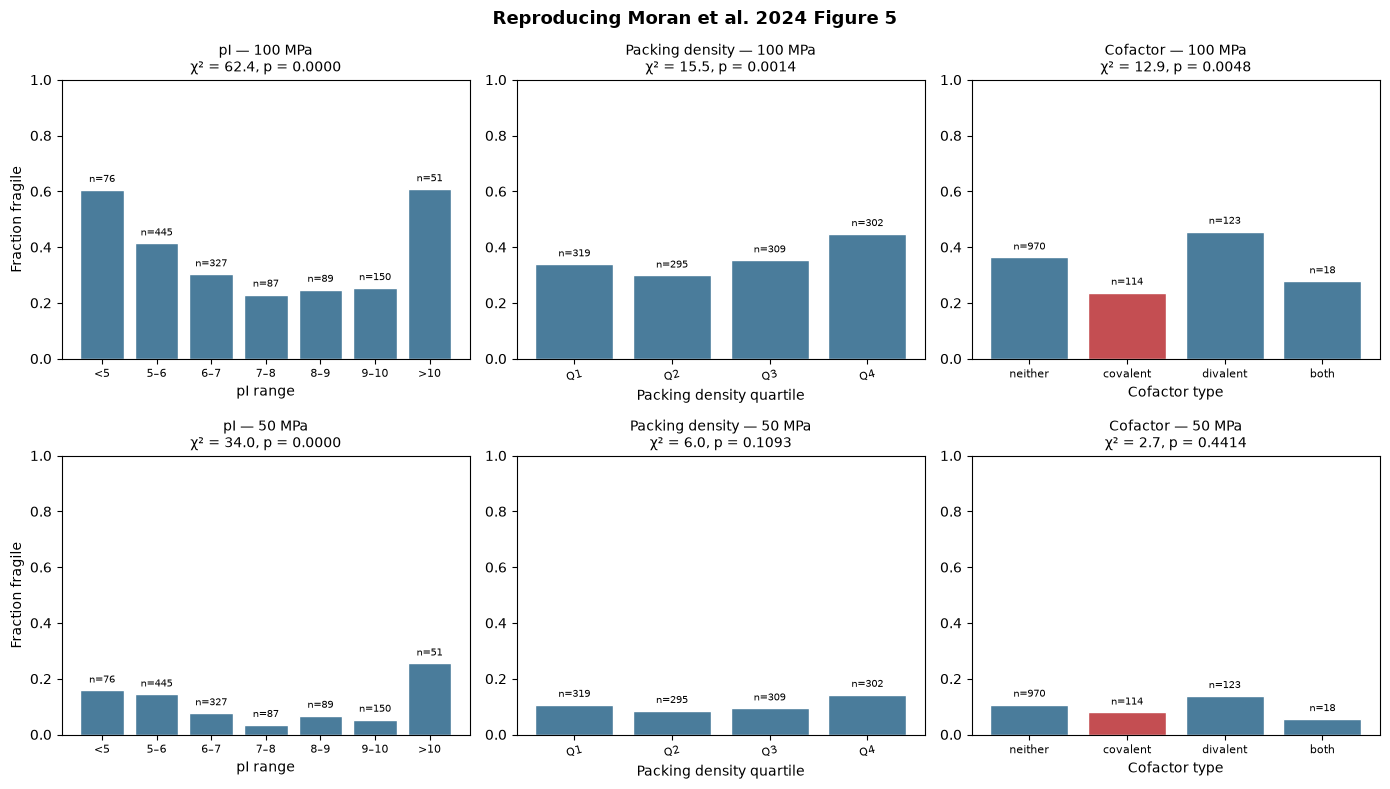

In [65]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Reproducing Moran et al. 2024 Figure 5',
             fontsize=13, fontweight='bold')

barcolor = '#4A7C9B'
highlightcolor = '#C44E52'

for row, (pressure, fcol, fraccol) in enumerate([
    ('100 MPa', 'fragile100', 'fracperturbed100'),
    ('50 MPa', 'fragile50', 'fracperturbed50'),
]):
    ax = axes[row, 0]
    result = run_chi2_binned(tthermodf, 'pI_x', fcol, piedges, pilabels)
    ct = result['table']
    xpos = range(len(ct))
    bars = ax.bar(xpos, ct['fracfragile'], color=barcolor, edgecolor='white')
    ax.set_xticks(xpos)
    ax.set_xticklabels(ct.index, fontsize=8)
    ax.set_ylabel('Fraction fragile')
    ax.set_xlabel('pI range')
    ax.set_title(f'pI — {pressure}\nχ² = {result["chi2"]:.1f}, p = {result["p"]:.4f}',
                 fontsize=10)
    ax.set_ylim(0, 1)
    for i, (bar, total) in enumerate(zip(bars, ct['total'])):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'n={total}', ha='center', va='bottom', fontsize=7)
    ax = axes[row, 1]
    result = run_chi2_binned(tthermodf, 'packing_density', fcol, quartilecuts, packlabels)
    ct = result['table']
    xpos = range(len(ct))
    bars = ax.bar(xpos, ct['fracfragile'], color=barcolor, edgecolor='white')
    ax.set_xticks(xpos)
    ax.set_xticklabels(ct.index, fontsize=8, rotation=15)
    ax.set_xlabel('Packing density quartile')
    ax.set_title(f'Packing density — {pressure}\nχ² = {result["chi2"]:.1f}, p = {result["p"]:.4f}',
                 fontsize=10)
    ax.set_ylim(0, 1)
    for i, (bar, total) in enumerate(zip(bars, ct['total'])):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'n={total}', ha='center', va='bottom', fontsize=7)

    ax = axes[row, 2]
    subset = tthermodf[['cofactors', fcol]].dropna().copy()
    subset['fragilestr'] = subset[fcol].map({True: 'fragile', False: 'notfragile'})
    ct = pd.crosstab(subset['cofactors'], subset['fragilestr'], margins=False)
    for val in ['notfragile', 'fragile']:
        if val not in ct.columns:
            ct[val] = 0
    ct = ct[['notfragile', 'fragile']]
    ct['total'] = ct['notfragile'] + ct['fragile']
    ct['fracfragile'] = ct['fragile'] / ct['total']
    chi2, p, dof, _ = chi2_contingency(ct[['notfragile', 'fragile']].values)

    plotorder = [c for c in ['neither', 'covalent', 'divalent', 'both'] if c in ct.index]
    ctordered = ct.loc[plotorder]
    xpos = range(len(ctordered))
    colors = [highlightcolor if cat == 'covalent' else barcolor for cat in ctordered.index]
    bars = ax.bar(xpos, ctordered['fracfragile'], color=colors, edgecolor='white')
    ax.set_xticks(xpos)
    ax.set_xticklabels(ctordered.index, fontsize=8)
    ax.set_xlabel('Cofactor type')
    ax.set_title(f'Cofactor — {pressure}\nχ² = {chi2:.1f}, p = {p:.4f}', fontsize=10)
    ax.set_ylim(0, 1)
    for i, (bar, total) in enumerate(zip(bars, ctordered['total'])):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'n={total}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig('validation_gate_figure.png', dpi=150, bbox_inches='tight')
plt.show()

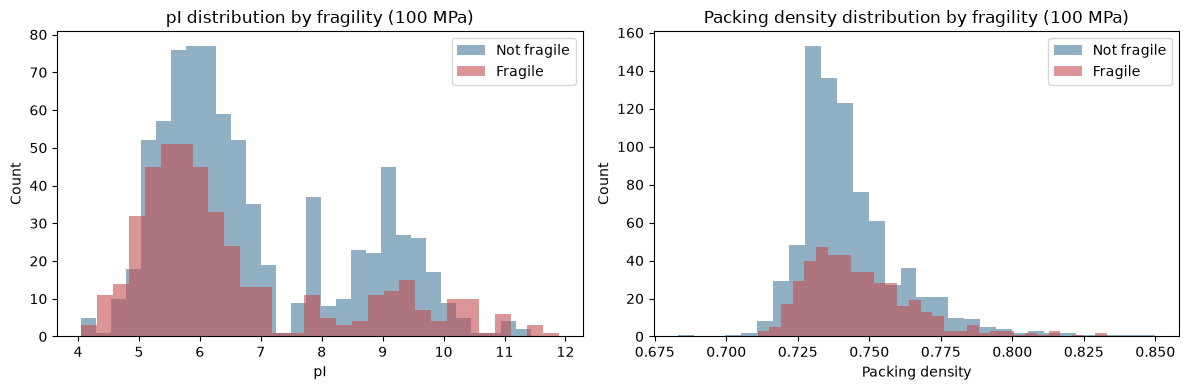

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
maskfrag = tthermodf['fragile100'] == True
masknotfrag = tthermodf['fragile100'] == False
axes[0].hist(tthermodf.loc[masknotfrag, 'pI_x'], bins=30, alpha=0.6,
             label='Not fragile', color='#4A7C9B')
axes[0].hist(tthermodf.loc[maskfrag, 'pI_x'], bins=30, alpha=0.6,
             label='Fragile', color='#C44E52')
axes[0].set_xlabel('pI')
axes[0].set_ylabel('Count')
axes[0].set_title('pI distribution by fragility (100 MPa)')
axes[0].legend()

axes[1].hist(tthermodf.loc[masknotfrag, 'packing_density'], bins=30, alpha=0.6,
             label='Not fragile', color='#4A7C9B')
axes[1].hist(tthermodf.loc[maskfrag, 'packing_density'], bins=30, alpha=0.6,
             label='Fragile', color='#C44E52')
axes[1].set_xlabel('Packing density')
axes[1].set_ylabel('Count')
axes[1].set_title('Packing density distribution by fragility (100 MPa)')
axes[1].legend()

plt.tight_layout()
plt.savefig('fragilityhistogram.png', dpi=150, bbox_inches='tight')
plt.show()